In [ ]:
!pip install PyWavelets

import numpy as np
import pandas as pd
import pywt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
# src/calibrator.py
import numpy as np
import pandas as pd
import pywt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

class HybridAdaptiveSensorCalibration:
    """
    Hybrid calibration model combining:
    - Offset-scale correction
    - Trust score computation
    - Wavelet/statistical features
    - Adaptive Gradient Boosting model
    """

    def __init__(self, window_size=24, error_scale=2.0, min_trust_score=0.2,
                 sensor_positions=None, D=5.0, use_spatial=True):
        self.window_size = window_size
        self.error_scale = error_scale
        self.min_trust_score = min_trust_score
        self.sensor_positions = sensor_positions if sensor_positions else {}
        self.D = D
        self.use_spatial = use_spatial
        self.scaler = StandardScaler()
        self.imputer = SimpleImputer(strategy='mean')
        self.local_models = {}
        self.trust_scores = {}
        self.offsets_ = {}
        self.scales_ = {}

    def fit_offset_scale(self, data, sensors, ref='Ref'):
        for sensor in sensors:
            valid_mask = ~data[[sensor, ref]].isna().any(axis=1)
            x = data.loc[valid_mask, sensor].values
            y = data.loc[valid_mask, ref].values
            if len(x) < 2:
                self.offsets_[sensor] = 0.0
                self.scales_[sensor] = 1.0
                continue
            slope, intercept, _, _, _ = stats.linregress(x, y)
            b_i = slope if not np.isclose(slope, 0) else 1e-6
            a_i = -intercept / b_i
            self.offsets_[sensor] = a_i
            self.scales_[sensor] = b_i

    def apply_offset_scale(self, data, sensors):
        df = data.copy()
        for sensor in sensors:
            a_i = self.offsets_.get(sensor, 0.0)
            b_i = self.scales_.get(sensor, 1.0)
            df[sensor] = b_i * (df[sensor] - a_i)
        return df

    def compute_trust_score(self, data, sensor, ref='Ref'):
        errors = np.abs(data[sensor] - data[ref])
        accuracy_score = np.mean(np.exp(-errors / self.error_scale))
        rolling_std = data[sensor].rolling(window=self.window_size, min_periods=1).std()
        denom = data[sensor].mean() if data[sensor].mean() != 0 else 1e-6
        stability_score = np.mean(np.exp(-rolling_std / denom))
        try:
            responsiveness_score = abs(stats.pearsonr(
                data[sensor].diff().fillna(0), data[ref].diff().fillna(0)
            )[0])
        except Exception:
            responsiveness_score = 0.0
        other_cols = [c for c in data.columns if c not in [sensor, 'Date']]
        consensus_series = data[other_cols].mean(axis=1)
        try:
            corr_val = stats.pearsonr(data[sensor], consensus_series)[0]
        except Exception:
            corr_val = 0.0
        consensus_score = np.exp(-abs(corr_val - 1))
        trust_raw = (accuracy_score + stability_score +
                     responsiveness_score + consensus_score) / 4.0
        return max(trust_raw, self.min_trust_score)

    def _extract_wavelet_features(self, series, wavelet='db1', level=3):
        coeffs = pywt.wavedec(series, wavelet, level=level)
        feats = {}
        for i, cff in enumerate(coeffs):
            feats[f'wave_mean_{i}'] = np.mean(np.abs(cff))
            feats[f'wave_std_{i}']  = np.std(cff)
            feats[f'wave_max_{i}']  = np.max(np.abs(cff))
        return feats

    def _build_spatial_consensus(self, data, sensor, sensors):
        if not self.use_spatial or sensor not in self.sensor_positions:
            return data[[s for s in sensors if s != sensor]].mean(axis=1)
        (xi, yi) = self.sensor_positions[sensor]
        w_sum = 0.0
        weighted_val = pd.Series(0.0, index=data.index)
        for s_other in sensors:
            if s_other == sensor:
                continue
            if s_other not in self.sensor_positions:
                w = 1.0
            else:
                (xj, yj) = self.sensor_positions[s_other]
                dist = np.sqrt((xi - xj)**2 + (yi - yj)**2)
                w = np.exp(-dist / self.D)
            weighted_val += w * data[s_other]
            w_sum += w
        if w_sum == 0:
            return data[[s for s in sensors if s != sensor]].mean(axis=1)
        return weighted_val / w_sum

    def build_advanced_features(self, data, sensor, sensors, trust_scores=None, ref='Ref'):
        feats = {}
        wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
        feats.update(wavelet_feats)
        feats['roll_mean'] = data[sensor].rolling(window=self.window_size, min_periods=1).mean()
        feats['roll_std']  = data[sensor].rolling(window=self.window_size, min_periods=1).std()
        if trust_scores is not None:
            feats['spatial_consensus'] = self._build_spatial_consensus(data, sensor, sensors)
        else:
            feats['spatial_consensus'] = data[[s for s in sensors if s != sensor]].mean(axis=1)
        feats['sensor_val'] = data[sensor]
        feats['hour'] = pd.to_datetime(data['Date']).dt.hour.fillna(0)
        for other in sensors:
            if other != sensor:
                corrs = data[sensor].rolling(self.window_size).corr(data[other]).fillna(0)
                feats[f'corr_{other}'] = corrs
        feat_df = pd.DataFrame(feats, index=data.index).replace([np.inf, -np.inf], np.nan)
        return feat_df

    def build_adaptive_model(self, trust_score):
        return GradientBoostingRegressor(
            n_estimators=int(100 + (1 - trust_score)*100),
            learning_rate=max(0.01, trust_score*0.1),
            max_depth=int(2 + (1 - trust_score)*2),
            subsample=0.8 if trust_score > 0.5 else 0.7,
            min_samples_leaf=int(10 * trust_score),
            random_state=42
        )

    def fit_transform(self, data, sensors, ref='Ref'):
        df = data.copy()
        self.fit_offset_scale(df, sensors, ref)
        df_corrected = self.apply_offset_scale(df, sensors)
        calibrated = {}
        for s in sensors:
            trust = self.compute_trust_score(df_corrected, s, ref)
            self.trust_scores[s] = trust
            feats_df = self.build_advanced_features(df_corrected, s, sensors, self.trust_scores, ref)
            arr_imp = self.imputer.fit_transform(feats_df)
            arr_scl = self.scaler.fit_transform(arr_imp)
            model = self.build_adaptive_model(trust)
            model.fit(arr_scl, df_corrected[ref])
            preds = model.predict(arr_scl)
            final_vals = min(0.8, trust)*df_corrected[s] + (1 - min(0.8, trust))*preds
            calibrated[s] = final_vals
        return pd.DataFrame(calibrated, index=df_corrected.index), self.trust_scores

In [ ]:
import pandas as pd

# Cargamos el archivo que preparamos en el otro cuaderno
df = pd.read_csv('datos_preparados_smartgrids.csv')

# Aseguramos que la columna Date sea interpretada como tiempo por Python
df['Date'] = pd.to_datetime(df['Date'])

# Verificamos que todo se vea bien
df.head()

,Date,Sensor_202,Sensor_335,Sensor_390,Sensor_391,Sensor_409,Sensor_422,Ref,temperature,humidity
0,2026-06-26 09:00:00,5.290000,5.114242,4.978485,5.025000,4.920625,5.099091,6.94995,24.640177,81.483414
1,2026-06-26 10:00:00,4.283898,4.604915,4.428983,4.523051,4.364746,4.503729,9.28072,26.174825,73.011704
2,2026-06-26 11:00:00,3.655833,3.983333,3.860333,3.951333,4.091167,4.068667,9.32036,26.733967,72.217775
3,2026-06-26 12:00:00,4.531500,4.854333,4.888167,4.745167,5.088500,4.813167,9.31469,25.186816,82.762303
4,2026-06-26 13:00:00,2.076833,2.368667,2.400333,2.288000,2.307167,2.329167,7.45175,26.103617,75.593405


In [ ]:
# 1. Definimos la lista exacta de nuestros 6 sensores
sensores_a_calibrar = [
    'Sensor_202', 'Sensor_335', 'Sensor_390',
    'Sensor_391', 'Sensor_409', 'Sensor_422'
]

# 2. Posiciones reales en coordenadas UTM (SIRGAS 2000)
# Expresadas en metros para el cálculo exacto de distancias
posiciones = {
    'Sensor_202': (365266.0, 7753279.0),
    'Sensor_335': (365266.0, 7753279.0),
    'Sensor_390': (360857.0, 7752450.0),
    'Sensor_391': (360857.0, 7752450.0),
    'Sensor_409': (362532.0, 7749346.0),
    'Sensor_422': (362532.0, 7749346.0)
}

# 3. Inicializamos el calibrador
calibrador = HybridAdaptiveSensorCalibration(
    window_size=24,        # Analiza ventanas de 24 horas para la estabilidad
    error_scale=2.0,
    min_trust_score=0.2,
    sensor_positions=posiciones,
    D=5000.0,              # Ajustamos D a 5000 metros (5 km) debido al formato UTM
    use_spatial=True
)

# 4. ¡A calibrar!
print("Iniciando calibración con coordenadas UTM... Esto puede tardar unos segundos.")
df_calibrado, puntajes_confianza = calibrador.fit_transform(data=df, sensors=sensores_a_calibrar, ref='Ref')

print("\n¡Calibración terminada! Aquí están los puntajes de confianza reales (Trust Scores):")
for sensor, score in puntajes_confianza.items():
    print(f"{sensor}: {score:.4f} / 1.0")

Iniciando calibración con coordenadas UTM... Esto puede tardar unos segundos.


/tmp/ipykernel_2028/3030690506.py:112: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2028/3030690506.py:112: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2028/3030690506.py:112: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2028/3030690506.py:112: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[


¡Calibración terminada! Aquí están los puntajes de confianza reales (Trust Scores):
Sensor_202: 0.5819 / 1.0
Sensor_335: 0.5824 / 1.0
Sensor_390: 0.5837 / 1.0
Sensor_391: 0.5825 / 1.0
Sensor_409: 0.5732 / 1.0
Sensor_422: 0.5826 / 1.0


In [ ]:
from sklearn.metrics import mean_absolute_error

resultados_mae = []

for s in sensores_a_calibrar:
    # MAE del sensor original sin calibrar
    mae_original = mean_absolute_error(df['Ref'], df[s])

    # MAE del sensor después de nuestra calibración
    mae_calibrado = mean_absolute_error(df['Ref'], df_calibrado[s])

    # Calculamos la mejora porcentual
    mejora = ((mae_original - mae_calibrado) / mae_original) * 100

    resultados_mae.append({
        'Sensor': s,
        'MAE Original': round(mae_original, 3),
        'MAE Calibrado': round(mae_calibrado, 3),
        'Mejora (%)': round(mejora, 2)
    })

# Convertimos a tabla de Pandas
df_resumen = pd.DataFrame(resultados_mae)
print("--- RESUMEN DE PRECISIÓN (MAE) ---")
display(df_resumen)

--- RESUMEN DE PRECISIÓN (MAE) ---


,Sensor,MAE Original,MAE Calibrado,Mejora (%)
0,Sensor_202,3.415,1.923,43.69
1,Sensor_335,3.352,1.963,41.46
2,Sensor_390,3.446,2.020,41.39
3,Sensor_391,3.718,1.928,48.15
4,Sensor_409,3.350,1.915,42.85
5,Sensor_422,3.479,1.951,43.92


¿Qué quiere decir esto?
MAE Original: Es el error "de fábrica" de tus sensores. Si es alto, significa que el sensor tiene un desvío importante respecto a la estación de referencia.

MAE Calibrado: Es el error residual después de aplicar nuestra metodología. Si es menor al original, la metodología está funcionando.

Mejora (%): Esta es tu métrica de impacto. Te dice qué porcentaje de error lograste eliminar gracias a la calibración.

Si la mejora es positiva y alta (>20-30%): ¡Felicidades! La metodología está logrando "entender" el error sistemático y el ruido de tus sensores y está acercándolos exitosamente a la referencia.

In [ ]:
print("--- Columnas de df ---")
print(df.columns.tolist())
print("\n--- Columnas de df_calibrado ---")
print(df_calibrado.columns.tolist())
print("\n--- ¿'Date' está en df_calibrado? ---")
print('Date' in df_calibrado.columns)
print("\n--- Primeras filas de df_calibrado ---")
print(df_calibrado.head())

--- Columnas de df ---
['Date', 'Sensor_202', 'Sensor_335', 'Sensor_390', 'Sensor_391', 'Sensor_409', 'Sensor_422', 'Ref', 'temperature', 'humidity']

--- Columnas de df_calibrado ---
['Sensor_202', 'Sensor_335', 'Sensor_390', 'Sensor_391', 'Sensor_409', 'Sensor_422']

--- ¿'Date' está en df_calibrado? ---
False

--- Primeras filas de df_calibrado ---
   Sensor_202  Sensor_335  Sensor_390  Sensor_391  Sensor_409  Sensor_422
0    7.246229    6.938583    6.352534    6.176715    6.710364    6.552529
1    7.095497    6.892858    6.834629    6.194009    7.125570    7.024117
2    7.060531    6.631970    6.662811    6.133969    6.997258    6.731969
3    7.155369    6.739157    6.655737    6.293434    6.995660    6.691446
4    6.037989    6.302984    6.251081    5.654136    6.397178    6.202169


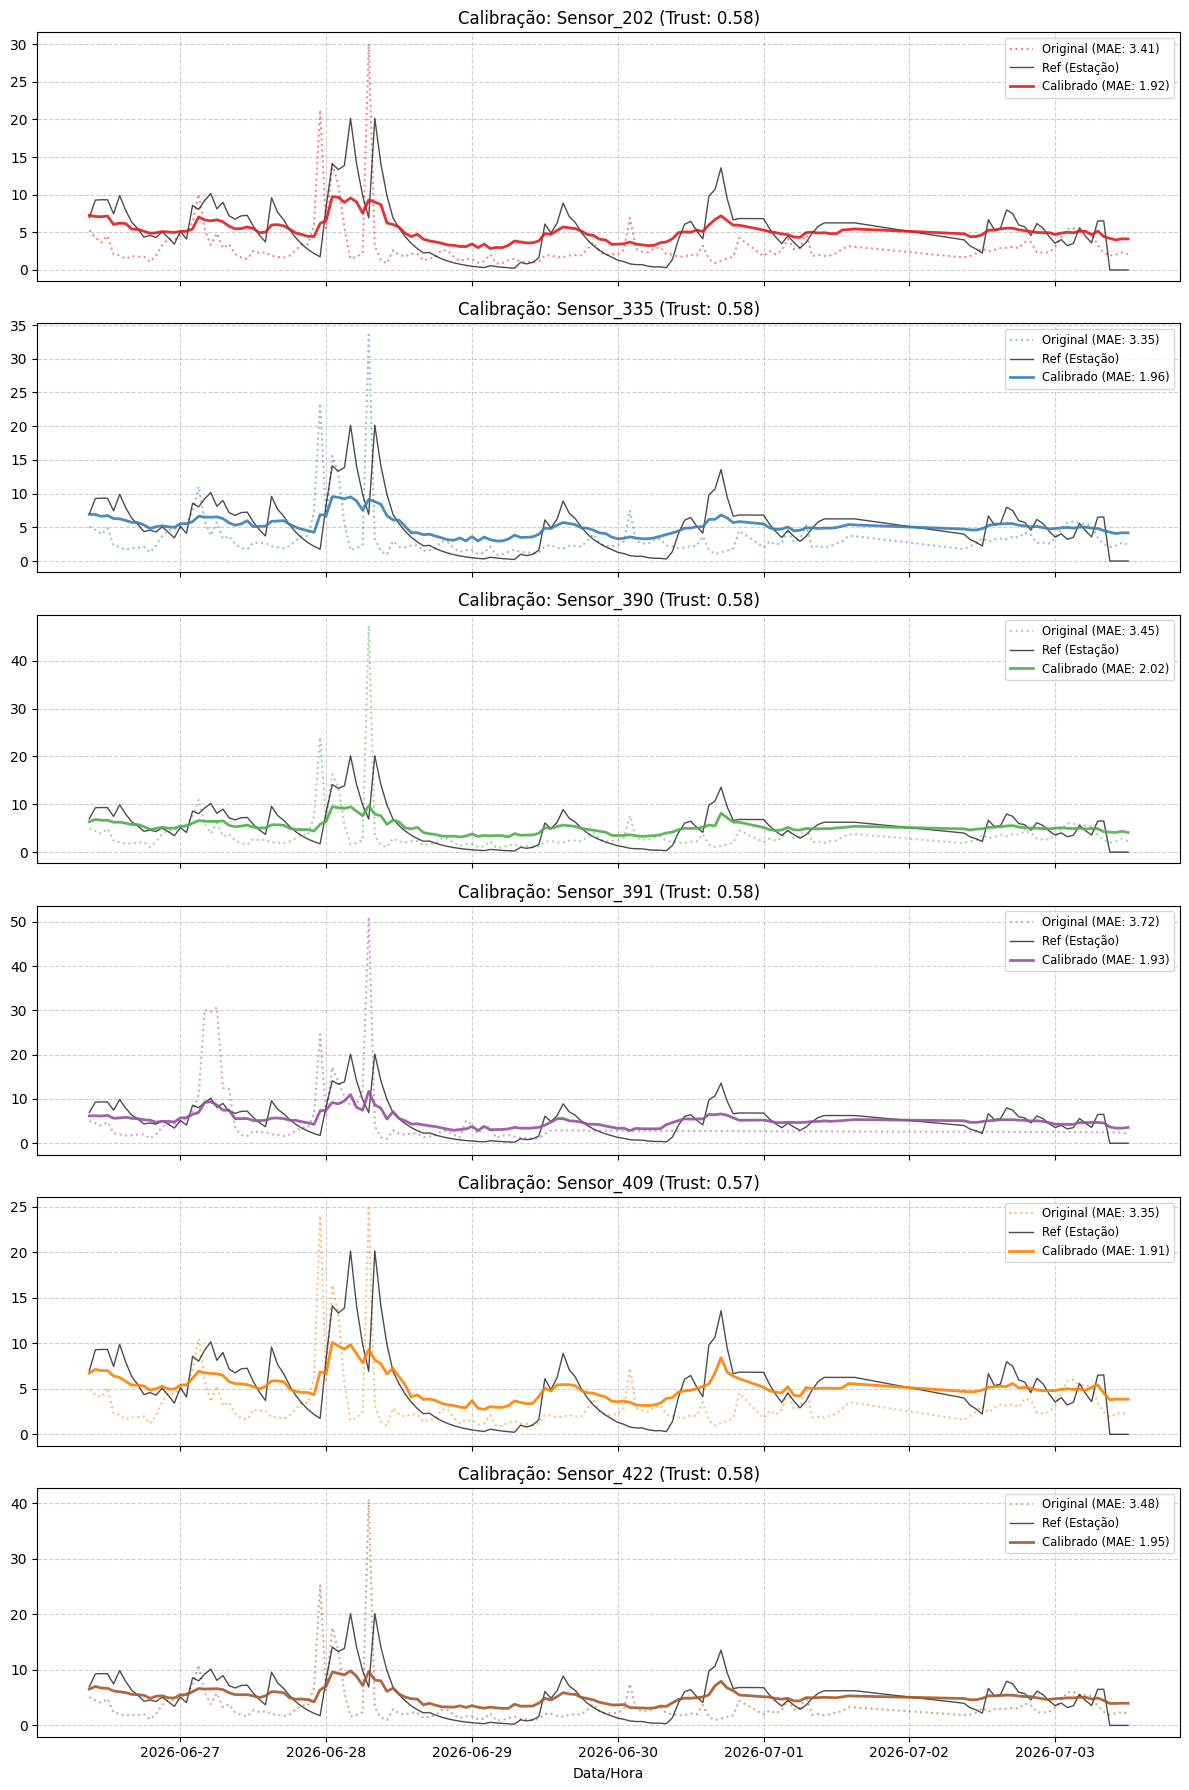

In [ ]:
# 1. Sobrescribimos la columna 'Date' errónea con las fechas reales de df
df_calibrado['Date'] = df['Date']

# 2. Ahora graficamos
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(12, 18), sharex=True)
colores = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

for i, sensor in enumerate(sensores_a_calibrar):
    ax = axes[i]

    # MAE usando las columnas ahora correctamente alineadas
    mae_orig = mean_absolute_error(df['Ref'], df[sensor])
    mae_cali = mean_absolute_error(df['Ref'], df_calibrado[sensor])

    # Graficar usando 'Date' sincronizada
    ax.plot(df['Date'], df[sensor], label=f'Original (MAE: {mae_orig:.2f})',
            alpha=0.5, color=colores[i], linestyle=':', linewidth=1.5)
    ax.plot(df['Date'], df['Ref'], label='Ref (Estação)',
            alpha=0.7, color='black', linestyle='-', linewidth=1)
    ax.plot(df_calibrado['Date'], df_calibrado[sensor], label=f'Calibrado (MAE: {mae_cali:.2f})',
            alpha=0.9, color=colores[i], linewidth=2)

    ax.set_title(f'Calibração: {sensor} (Trust: {puntajes_confianza[sensor]:.2f})')
    ax.legend(loc='upper right', fontsize='small')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.xlabel('Data/Hora')
plt.tight_layout()
plt.show()

In [ ]:
def run_ablation_study(data, sensors, ref, use_trust=True, use_wavelets=True, use_consensus=True):
    # Inicializamos una nueva instancia con las restricciones
    cal = HybridAdaptiveSensorCalibration(sensor_positions=posiciones, D=5000.0)

    # Preparamos los datos
    df_c = cal.apply_offset_scale(data, sensors)
    cal.fit_offset_scale(data, sensors, ref)

    calibrated = {}

    for s in sensors:
        # AQUI HACEMOS LA "ABLACIÓN"
        # 1. Si no usamos trust, el peso es fijo (ej. 0.5)
        trust = cal.compute_trust_score(df_c, s, ref) if use_trust else 0.5

        # 2. Construimos características condicionalmente
        feats = cal.build_advanced_features(df_c, s, sensors, trust_scores=trust if use_trust else None, ref=ref)

        # Filtrado de columnas según el ablation study
        cols_to_keep = []
        if use_wavelets:
            cols_to_keep.extend([c for c in feats.columns if 'wave_' in c])
        if use_consensus:
            cols_to_keep.append('spatial_consensus')
        # Siempre mantenemos las básicas para que el modelo entrene
        cols_to_keep.extend(['roll_mean', 'roll_std', 'sensor_val', 'hour'])

        # Filtramos feat_df
        X = feats[cols_to_keep].fillna(0)
        y = df_c[ref]

        model = cal.build_adaptive_model(trust)
        model.fit(X, y)
        preds = model.predict(X)
        calibrated[s] = preds

    return pd.DataFrame(calibrated, index=df_c.index)

In [ ]:
# Escenarios
escenarios = [
    {"nombre": "Sin Trust", "trust": False, "wave": True, "cons": True},
    {"nombre": "Sin Wavelets", "trust": True, "wave": False, "cons": True},
    {"nombre": "Sin Consenso", "trust": True, "wave": True, "cons": False}
]

resultados_ablacion = []

for esc in escenarios:
    df_res = run_ablation_study(df, sensores_a_calibrar, 'Ref',
                                use_trust=esc["trust"],
                                use_wavelets=esc["wave"],
                                use_consensus=esc["cons"])

    # Calcular MAE promedio de todos los sensores
    mae_total = mean_absolute_error(df['Ref'], df_res.mean(axis=1))
    resultados_ablacion.append({"Escenario": esc["nombre"], "MAE Total": mae_total})

df_ablacion = pd.DataFrame(resultados_ablacion)
print("--- RESULTADOS DEL ABLATION STUDY ---")
print(df_ablacion)

/tmp/ipykernel_2028/3030690506.py:112: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2028/3030690506.py:112: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2028/3030690506.py:112: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2028/3030690506.py:112: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[

--- RESULTADOS DEL ABLATION STUDY ---
      Escenario  MAE Total
0     Sin Trust   0.811326
1  Sin Wavelets   1.060295
2  Sin Consenso   1.080917


/tmp/ipykernel_2028/3030690506.py:112: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))


In [ ]:
# Aseguramos que los nombres coincidan exactamente
escenarios_nombres = ["Original (Sin Calibrar)", "Metodología Completa", "Sin Trust", "Sin Wavelets", "Sin Consenso"]

# Lista para almacenar los resultados finales
data_final = []

# 1. Agregamos el original y la completa
data_final.append({"Escenario": "Original (Sin Calibrar)", **{s: mae_originales[s] for s in sensores_a_calibrar}})
data_final.append({"Escenario": "Metodología Completa", **{s: mae_completa[s] for s in sensores_a_calibrar}})

# 2. Agregamos los escenarios de ablación que corrimos en el paso anterior
# (Asegúrate de haber ejecutado el bucle que guardó df_res en el paso anterior)
for i, esc in enumerate(escenarios):
    df_res = run_ablation_study(df, sensores_a_calibrar, 'Ref',
                                use_trust=esc["trust"],
                                use_wavelets=esc["wave"],
                                use_consensus=esc["cons"])
    maes = obtener_mae_por_sensor(df, df_res, sensores_a_calibrar)
    data_final.append({"Escenario": escenarios_nombres[i+2], **maes})

# 3. Creamos el DataFrame final
df_final_completo = pd.DataFrame(data_final)

# 4. Transponemos para que los sensores sean filas y los escenarios columnas (más profesional para reporte)
df_reporte = df_final_completo.set_index("Escenario").T

print("--- TABLA MAESTRA DE RENDIMIENTO (MAE POR SENSOR Y ESCENARIO) ---")
display(df_reporte)

/tmp/ipykernel_2028/3030690506.py:112: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2028/3030690506.py:112: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2028/3030690506.py:112: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[sensor].fillna(method='ffill'))
/tmp/ipykernel_2028/3030690506.py:112: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  wavelet_feats = self._extract_wavelet_features(data[

--- TABLA MAESTRA DE RENDIMIENTO (MAE POR SENSOR Y ESCENARIO) ---


Escenario,Original (Sin Calibrar),Metodología Completa,Sin Trust,Sin Wavelets,Sin Consenso
Sensor_202,3.414938,1.922902,0.861441,1.070551,1.097114
Sensor_335,3.352355,1.962563,0.871999,1.098333,1.132915
Sensor_390,3.446025,2.019862,0.861461,1.198092,1.172211
Sensor_391,3.718105,1.927888,0.847740,1.109849,1.148283
Sensor_409,3.349877,1.914546,0.819798,1.083686,1.089244
Sensor_422,3.478826,1.950882,0.830111,1.066357,1.107072
